##### **Import Dependencies**

###### Create a BMI Calculator model based on height and weight and give proper category to the user also suggest proper diet

In [38]:
from langchain_openai import ChatOpenAI
from typing import TypedDict
from pydantic import BaseModel
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage

In [39]:
from typing import Literal

from pydantic import Field

load_dotenv()
class BMISchema(TypedDict):
    height_m : float
    weight_kg : float
    bmi_index : float
    category: Literal['under weight', 'perfect', 'obese'] = Field(description ='Provide category based on BMI Index')
    diet: str=Field(description='Provide proper Diet based on BMI Index.')


class SuggestionSchema(BaseModel):
    category: Literal['under weight', 'perfect', 'obese'] = Field(description ='Provide category based on BMI Index')
    diet: str=Field(description='Provide proper Diet based on BMI Index.')



In [40]:
model = ChatOpenAI()
suggestor_model= model.with_structured_output(SuggestionSchema)

c:\Users\test\Desktop\LangGraph\Practice\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [41]:
def bmi_calculator(state: BMISchema):
    '''This Function will calculate BMI using weight and height of the user'''
    weight = state['weight_kg']
    height = state['height_m']

    bmi = round(weight/(height**2),2)

    return {'bmi_index':bmi}

In [42]:
def trainer(state:BMISchema):

    #prompt
    messages = [
        SystemMessage(content='You are a Guy Traineer, who guide people professionally'),
        HumanMessage(content=f"""
            Based on the BMI Index of the person: BMI Index = {state['bmi_index']} give him in which category the person belongs among "under weight","perfect","obese"
            Based on the BMI Index of the person: BMI Index = {state['bmi_index']}\n Suggest him the proper diet which he could follow to maintained the good health.
                     """)
    ]
    #LLM Call with structue model
    response = suggestor_model.invoke(messages)
    
    #return
    return {'category':response.category, 'diet': response.diet}

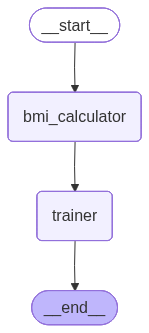

In [43]:
graph = StateGraph(BMISchema)

## add Node
graph.add_node('bmi_calculator', bmi_calculator)
graph.add_node('trainer', trainer)

## add edges
graph.add_edge(START, 'bmi_calculator')
graph.add_edge('bmi_calculator','trainer')
graph.add_edge('trainer', END)

final_graph = graph.compile()

final_graph


In [47]:
initial_state = {
    'height_m': 1.69, 
    'weight_kg': 82,
    'bmi_index': "",
    'category': "",
    'diet':""
}
response = final_graph.invoke(initial_state)
response

{'height_m': 1.69,
 'weight_kg': 82,
 'bmi_index': 28.71,
 'category': 'obese',
 'diet': "You should focus on a balanced diet rich in fruits, vegetables, whole grains, lean protein, and healthy fats. Limit intake of processed foods, sugary drinks, and high-fat foods. It's important to stay hydrated and incorporate regular exercise into your routine."}